In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df=pd.read_excel("/content/IMDb_500_Movies_Full.xlsx")
df.head(10)

,Movie Name,Release Year,Genres,Rating,Votes,Director,Top Actors
0,Sandigdham,2026,Action,10.0,1000,Parda Saradhi Kommoju,"Nihal, Ch Arjun, Priya Deshpag, Kajal Tiwari, ..."
1,A Black History Tour of St. Louis,2025,Documentary,10.0,11,Tony West,"Jobyna Foster, Vivian Gibson, Lynne M. Jackson..."
2,Ruby Island,2026,Thriller,10.0,11,Freddy Moyano,"Freddy Moyano, Megan Carpenter, Christopher Pa..."
3,The Story of Nehanda,2021,History,10.0,7,Sydney Taivavashe,"Eunice Tava, Tariro Washe, Larry Greeff, John ..."
4,My boyfriends daddy is my man,2022,Adult,10.0,7,Jill Watson,"Steve Long, Mikayla Watson"
5,Zakhma Toh Chardikala Tak,2026,Drama,9.9,1080,Amarjit Singh Saron,"Naiqra Dhillon, Roopi Gill, Aks Mehraj, Jarnai..."
6,I Forced an AI to Play a Kids Adventure Game,2023,"Adventure,Comedy,Drama",9.9,533,NaN,"Pajama Sam, Sentient Boat, Communist Carrot, C..."
7,Cannabis and Cancer,2026,Documentary,9.9,130,Raphael E. Cuomo,NaN
8,96 Pounds of Dynamite,2026,Documentary,9.9,78,Loren Goldfarb,NaN
9,El Proyecto que Amenaza a México,2025,Documentary,9.9,78,Carolina Jefillysh,NaN


In [38]:
df.shape

(500, 7)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie Name    500 non-null    object 
 1   Release Year  500 non-null    object 
 2   Genres        500 non-null    object 
 3   Rating        500 non-null    float64
 4   Votes         500 non-null    int64  
 5   Director      476 non-null    object 
 6   Top Actors    323 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 27.5+ KB


In [40]:
df.describe()

,Rating,Votes
count,500.000000,500.000000
mean,9.661400,49.842000
std,0.092451,126.051191
min,9.500000,5.000000
25%,9.600000,9.000000
50%,9.600000,14.000000
75%,9.700000,32.500000
max,10.000000,1151.000000


In [41]:
df.nunique()

,0
Movie Name,500
Release Year,40
Genres,77
Rating,6
Votes,117
Director,455
Top Actors,323


In [42]:
df["Top Actors"] = df["Top Actors"].fillna("Unknown")
df["Director"] = df["Director"].fillna("Unknown")

In [43]:
df.head(10)

,Movie Name,Release Year,Genres,Rating,Votes,Director,Top Actors
0,Sandigdham,2026,Action,10.0,1000,Parda Saradhi Kommoju,"Nihal, Ch Arjun, Priya Deshpag, Kajal Tiwari, ..."
1,A Black History Tour of St. Louis,2025,Documentary,10.0,11,Tony West,"Jobyna Foster, Vivian Gibson, Lynne M. Jackson..."
2,Ruby Island,2026,Thriller,10.0,11,Freddy Moyano,"Freddy Moyano, Megan Carpenter, Christopher Pa..."
3,The Story of Nehanda,2021,History,10.0,7,Sydney Taivavashe,"Eunice Tava, Tariro Washe, Larry Greeff, John ..."
4,My boyfriends daddy is my man,2022,Adult,10.0,7,Jill Watson,"Steve Long, Mikayla Watson"
5,Zakhma Toh Chardikala Tak,2026,Drama,9.9,1080,Amarjit Singh Saron,"Naiqra Dhillon, Roopi Gill, Aks Mehraj, Jarnai..."
6,I Forced an AI to Play a Kids Adventure Game,2023,"Adventure,Comedy,Drama",9.9,533,Unknown,"Pajama Sam, Sentient Boat, Communist Carrot, C..."
7,Cannabis and Cancer,2026,Documentary,9.9,130,Raphael E. Cuomo,Unknown
8,96 Pounds of Dynamite,2026,Documentary,9.9,78,Loren Goldfarb,Unknown
9,El Proyecto que Amenaza a México,2025,Documentary,9.9,78,Carolina Jefillysh,Unknown


In [44]:
df

,Movie Name,Release Year,Genres,Rating,Votes,Director,Top Actors
0,Sandigdham,2026,Action,10.0,1000,Parda Saradhi Kommoju,"Nihal, Ch Arjun, Priya Deshpag, Kajal Tiwari, ..."
1,A Black History Tour of St. Louis,2025,Documentary,10.0,11,Tony West,"Jobyna Foster, Vivian Gibson, Lynne M. Jackson..."
2,Ruby Island,2026,Thriller,10.0,11,Freddy Moyano,"Freddy Moyano, Megan Carpenter, Christopher Pa..."
3,The Story of Nehanda,2021,History,10.0,7,Sydney Taivavashe,"Eunice Tava, Tariro Washe, Larry Greeff, John ..."
4,My boyfriends daddy is my man,2022,Adult,10.0,7,Jill Watson,"Steve Long, Mikayla Watson"
...,...,...,...,...,...,...,...
495,The Return of Uncle Benon,2011,Action,9.5,208,Nabwana I.G.G.,"Bukenya Charles, Lutalo, Sserunya Ernest, Kizz..."
496,Ego Raman,2026,Drama,9.5,162,Ganesan Nachimuthu,"Ciby Bhuvana Chandran, Chappani Boys Murali, K..."
497,The Land of Women,2024,Fantasy,9.5,141,Yang Hai Ting,Unknown
498,Bittersweet Memories: 14 Dias Isolados Para Fa...,2023,Documentary,9.5,130,Victor Schiavon,"Leandro Bife, Victor Schiavon"


In [45]:
df["Top Actors"].isnull().sum()

np.int64(0)

In [46]:
df["Director"].isnull().sum()

np.int64(0)

In [47]:
df.duplicated().sum()

np.int64(0)

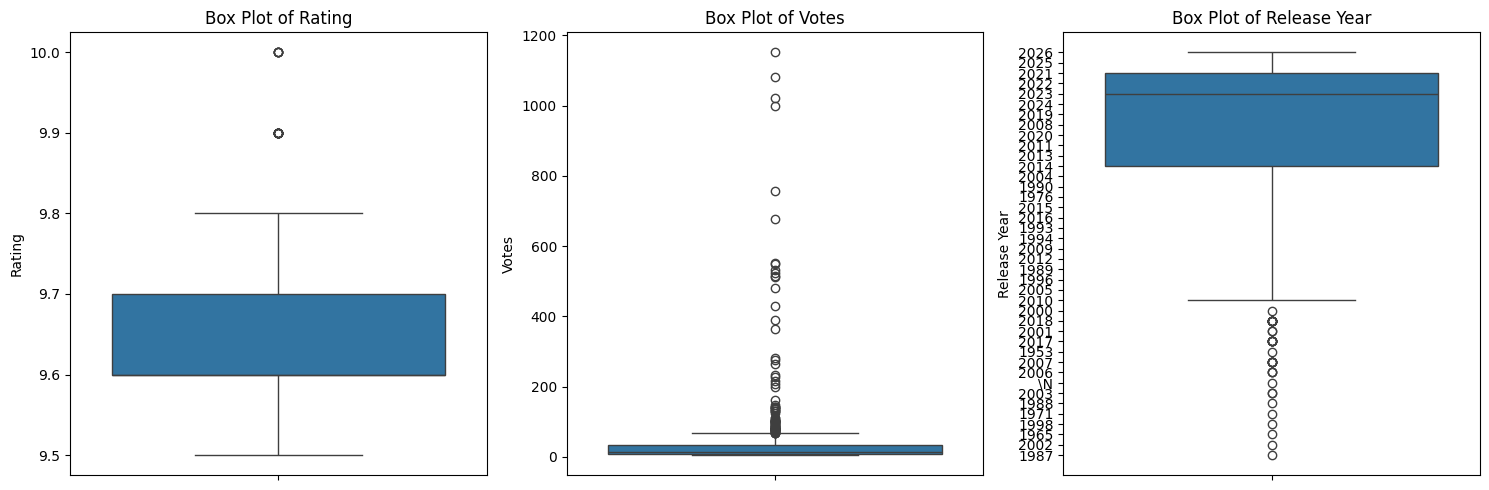

In [48]:
numerical_cols = ['Rating', 'Votes', 'Release Year']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [49]:
df.columns.to_list()


['Movie Name',
 'Release Year',
 'Genres',
 'Rating',
 'Votes',
 'Director',
 'Top Actors']

In [50]:
df.describe(include=object)

,Movie Name,Release Year,Genres,Director,Top Actors
count,500,500,500,500,500
unique,500,40,77,456,324
top,The Broken Promise,2025,Documentary,Unknown,Unknown
freq,1,76,233,24,177


In [51]:
print("\n--- Top 10 Movies by Rating (with consideration for Votes) ---")
print(df.sort_values(by=['Rating', 'Votes'], ascending=[False, False]).head(10)[['Movie Name', 'Rating', 'Votes', 'Director', 'Genres']])


--- Top 10 Movies by Rating (with consideration for Votes) ---
                                     Movie Name  Rating  Votes  \
0                                    Sandigdham    10.0   1000   
1             A Black History Tour of St. Louis    10.0     11   
2                                   Ruby Island    10.0     11   
3                          The Story of Nehanda    10.0      7   
4                 My boyfriends daddy is my man    10.0      7   
5                     Zakhma Toh Chardikala Tak     9.9   1080   
6  I Forced an AI to Play a Kids Adventure Game     9.9    533   
7                           Cannabis and Cancer     9.9    130   
8                         96 Pounds of Dynamite     9.9     78   
9              El Proyecto que Amenaza a México     9.9     78   

                Director                  Genres  
0  Parda Saradhi Kommoju                  Action  
1              Tony West             Documentary  
2          Freddy Moyano                Thriller  
3    

In [52]:
print("\n--- Distribution of Genres ---")
print(df['Genres'].value_counts())


--- Distribution of Genres ---
Genres
Documentary                    233
Drama                           79
Comedy                          20
Drama,Romance                   13
Music                           13
                              ... 
Sci-Fi,Thriller                  1
Adventure,Documentary,Sport      1
Drama,Mystery,Romance            1
Comedy,Drama,Family              1
Fantasy                          1
Name: count, Length: 77, dtype: int64


In [53]:
genres_series = df['Genres'].str.split(',').explode()

In [54]:
print("\n--- Sum of Genre Counts ---")
print(genres_series.value_counts().sum())


--- Sum of Genre Counts ---
648


/tmp/ipykernel_7020/2814293316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=filtered_genres_series, order=top_10_genres, palette='viridis')


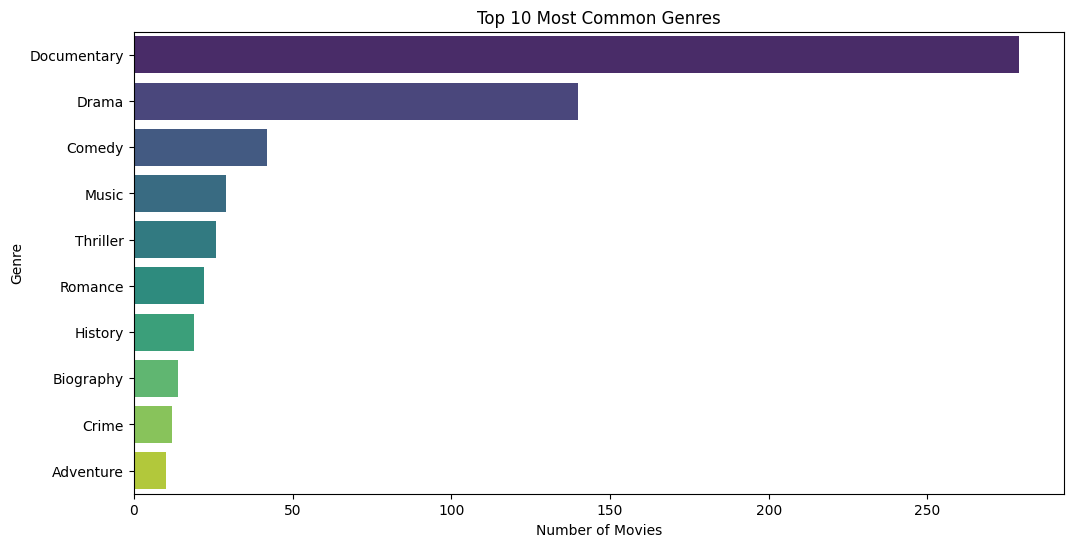

In [55]:
plt.figure(figsize=(12, 6))
top_10_genres = genres_series.value_counts().head(10).index

filtered_genres_series = genres_series[genres_series.isin(top_10_genres)]
sns.countplot(y=filtered_genres_series, order=top_10_genres, palette='viridis')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

In [56]:
print("\n--- Movies Released Per Year (Top 10 Years) ---")
df['Release Year'] = pd.to_numeric(df['Release Year'], errors='coerce')
release_year_counts = df['Release Year'].dropna().astype(int).value_counts().sort_index(ascending=False)
print(release_year_counts.head(10))


--- Movies Released Per Year (Top 10 Years) ---
Release Year
2026    40
2025    76
2024    38
2023    59
2022    59
2021    31
2020    21
2019    23
2018    12
2017     8
Name: count, dtype: int64


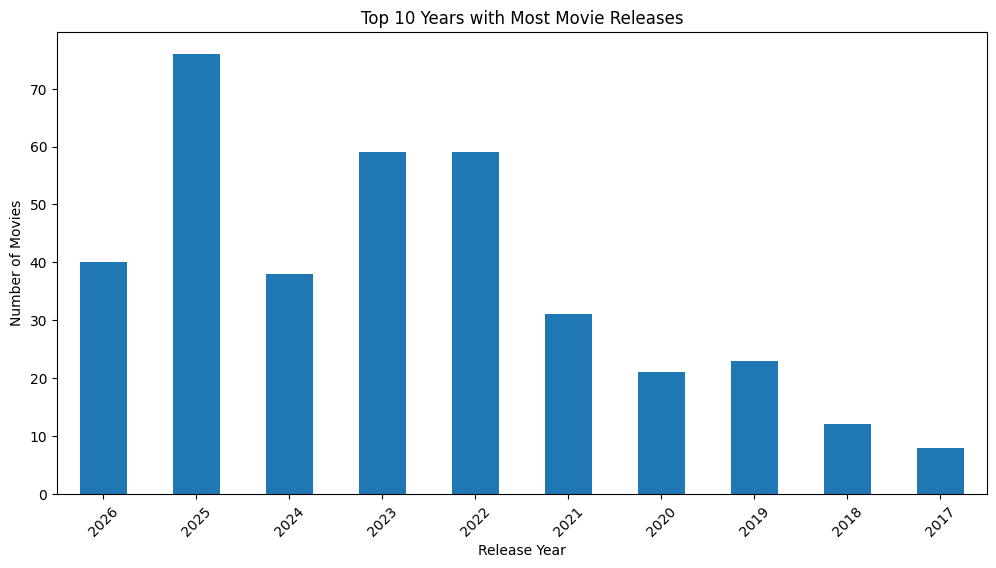

In [57]:
plt.figure(figsize=(12, 6))
release_year_counts.head(10).plot(kind='bar')
plt.title('Top 10 Years with Most Movie Releases')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

In [58]:
print("\n--- Top 10 Directors by Number of Movies ---")
directors_counts = df[df['Director'] != 'Unknown']['Director'].value_counts()
print(directors_counts.head(10))


--- Top 10 Directors by Number of Movies ---
Director
Claudio Costa             4
Alonso O. Lara            4
I. Kolyada                4
António Borges Correia    4
Arthur Balder             2
Uilson França             2
Michael Loukinen          2
Leontina Vatamanu         2
Nicole Zwiren             2
Lilou Lemaire             2
Name: count, dtype: int64


/tmp/ipykernel_7020/2798236602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=directors_counts.head(10).values, y=directors_counts.head(10).index, palette='magma')


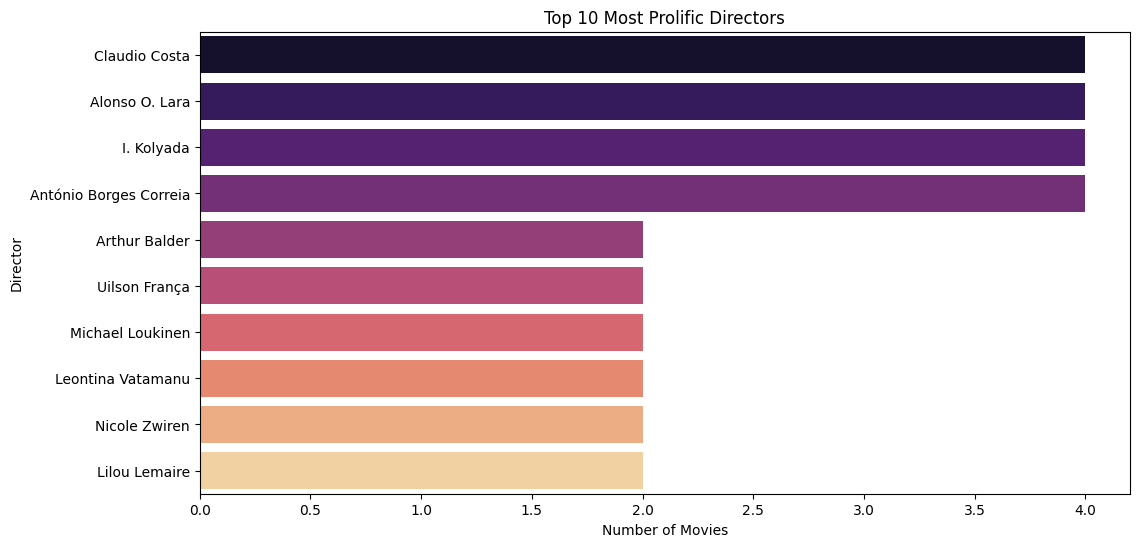

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(x=directors_counts.head(10).values, y=directors_counts.head(10).index, palette='magma')
plt.title('Top 10 Most Prolific Directors')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.show()

In [60]:
print("\n--- Average Rating by Genre (Top 10 Genres) ---")
genre_ratings = df.assign(Genres=df['Genres'].str.split(',')).explode('Genres').groupby('Genres')['Rating'].mean().sort_values(ascending=False)
print(genre_ratings.head(10))


--- Average Rating by Genre (Top 10 Genres) ---
Genres
Adult          9.840000
History        9.673684
Documentary    9.668817
Sci-Fi         9.666667
Adventure      9.660000
Comedy         9.654762
Music          9.651724
Thriller       9.650000
Drama          9.643571
Mystery        9.642857
Name: Rating, dtype: float64


/tmp/ipykernel_7020/895562136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.head(10).values, y=genre_ratings.head(10).index, palette='rocket')


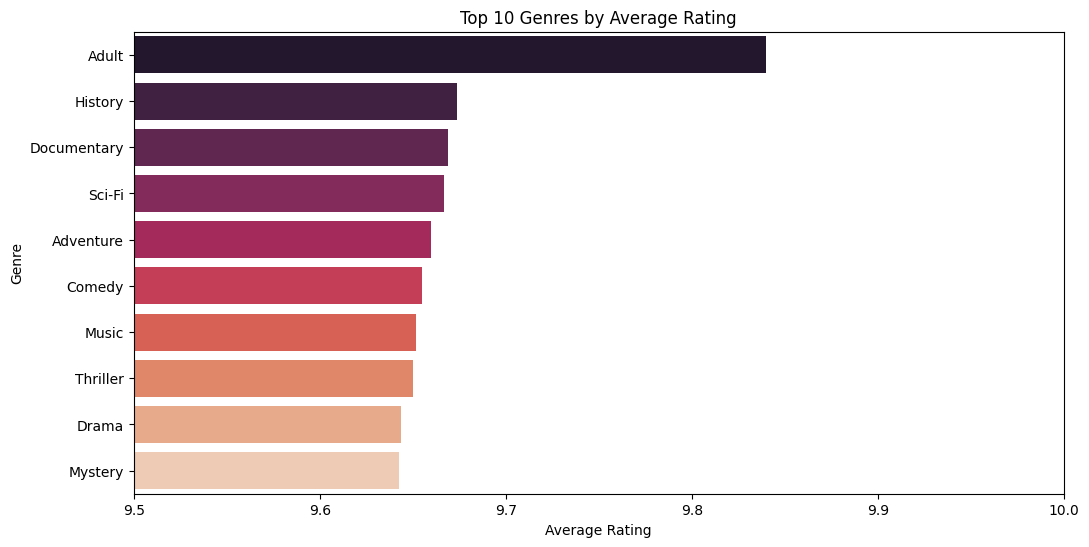

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_ratings.head(10).values, y=genre_ratings.head(10).index, palette='rocket')
plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(9.5, 10.0)
plt.show()


--- Relationship between Rating, Votes and Release Year ---


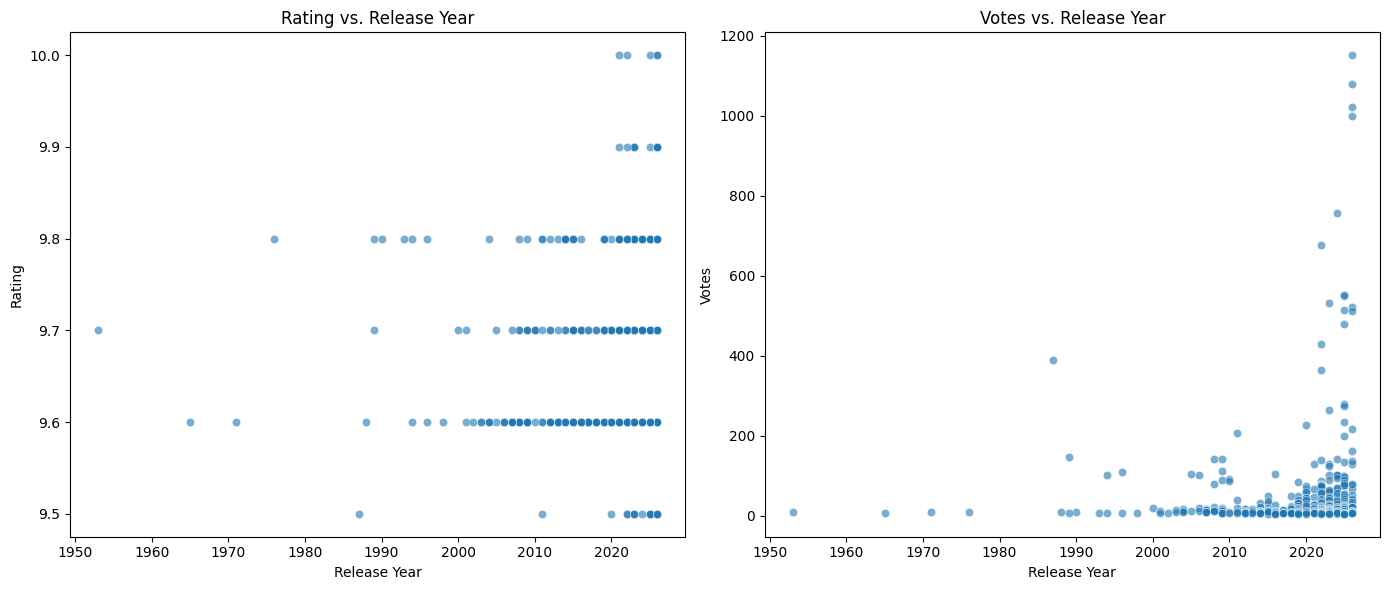

In [62]:
print("\n--- Relationship between Rating, Votes and Release Year ---")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Release Year', y='Rating', data=df, alpha=0.6)
plt.title('Rating vs. Release Year')
plt.subplot(1, 2, 2)
sns.scatterplot(x='Release Year', y='Votes', data=df, alpha=0.6)
plt.title('Votes vs. Release Year')
plt.tight_layout()
plt.show()

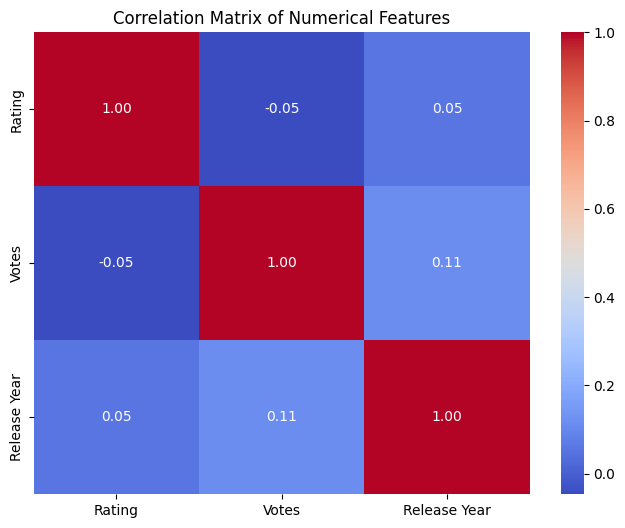

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Rating', 'Votes', 'Release Year']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()